# Assignment 2

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats


In [6]:
df = pd.read_csv('dataset.csv', usecols=('Player ID', 'Player Name', 'Short Name', 'Position', 'Position Code', 'Age', 'Age Group', 'Matches Played', 'Passes', 'Passes Completed', 'Passing Accuracy'))
df.tail(10)

,Player ID,Player Name,Short Name,Position,Position Code,Age,Age Group,Matches Played,Passes,Passes Completed,Passing Accuracy
1238,405879,Wilson Isidor,ISIDOR,Forward,FW,25,Younger,3,21,18,85.70%
1239,448159,Wout WEGHORST,WEGHORST,Forward,FW,33,Older,1,7,4,57.10%
1240,510922,Yan DIOMANDE,YAN DIOMANDE,Forward,FW,19,Younger,4,142,127,89.40%
1241,506483,Yassin FORTUNE,FORTUNE,Forward,FW,27,Younger,1,5,5,100.00%
1242,423658,Yeremy PINO,YEREMY,Forward,FW,23,Younger,2,29,25,86.20%
1243,441316,Yoane WISSA,WISSA,Forward,FW,29,Older,4,69,60,87.00%
1244,406231,Yunus AKGUN,YUNUS,Forward,FW,25,Younger,2,52,41,78.80%
1245,419463,YUSUF ABDURISAG,YUSUF,Forward,FW,26,Younger,2,14,9,64.30%
1246,448112,Zeki AMDOUNI,AMDOUNI,Forward,FW,25,Younger,4,11,8,72.70%
1247,433461,ZIZO,ZIZO,Forward,FW,30,Older,4,27,23,85.20%


# 

##### In average, what is the passing accuracy among players, excluding players who have no passing attempts.

Population: All players attending the WC 2026 \
Sample: 40 random players with a position ratio of: 1:1:1:1 (10 players from each position)

Exclude players who have no passes

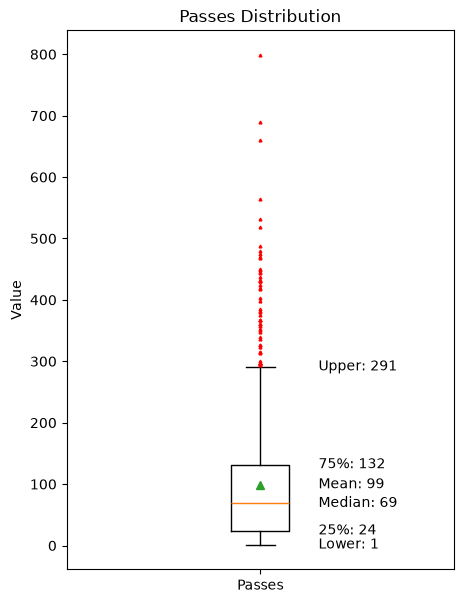

In [7]:
df = df[df['Passes'] > 0]
stats = boxplot_stats(df['Passes'])[0]
labels = {
        'Lower': stats['whislo'],
        '25%': stats['q1'],
        'Median': stats['med'],
        'Mean': stats['mean'],
        '75%': stats['q3'],
        'Upper': stats['whishi'],
        }

plt.figure(figsize=(5, 7))

plt.boxplot([df['Passes']], tick_labels= ['Passes'], showmeans=True,  flierprops=dict(
        marker='^',
        markerfacecolor='red',
        markeredgecolor='red',
        markersize=2
    ))

plt.title(f'Passes Distribution')
plt.ylabel('Value')
for name, value in labels.items():
        plt.text(
                1.15,                 
                value,
                f'{name}: {value:.0f}',
                va='center'
        )

plt.show()


In [8]:
Q1 = df['Passes'].quantile(0.25)

df = df[df['Passes'] >= Q1]
min(df['Passes'])

24

In [9]:
df = df.sort_values('Passes', ascending=True)
df['Passing Accuracy Rate'] = round(df['Passes Completed'] / df['Passes'],3)
# df.head(20)

In [10]:
sample_size = 50

In [11]:
pos_proportion = df['Position'].value_counts(normalize=True)
pos_observation = (pos_proportion * sample_size).round().astype(int)

In [12]:
print(pos_proportion)
print(pos_observation)

Position
Defender      0.388527
Midfielder    0.342894
Forward       0.194263
Goalkeeper    0.074316
Name: proportion, dtype: float64
Position
Defender      19
Midfielder    17
Forward       10
Goalkeeper     4
Name: proportion, dtype: int64


Sampling

In [13]:
sample = pd.DataFrame()
for position in df['Position'].unique():
    sample_pos = df[df['Position'] == position]
    temp_sample = sample_pos.sample(pos_observation[position],random_state = 10)
    sample = pd.concat([sample, temp_sample])

In [14]:
sample.describe()

,Player ID,Age,Matches Played,Passes,Passes Completed,Passing Accuracy Rate
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,425059.900000,26.980000,3.820000,135.440000,118.22000,0.847600
std,55742.991749,3.997397,1.612325,111.155372,104.27716,0.073769
min,229397.000000,20.000000,1.000000,27.000000,23.00000,0.638000
25%,403554.250000,24.250000,3.000000,59.250000,50.50000,0.819250
50%,427141.000000,26.000000,4.000000,107.000000,85.00000,0.860000
75%,462872.500000,29.000000,4.000000,147.500000,128.50000,0.900000
max,506329.000000,38.000000,8.000000,450.000000,422.00000,0.966000


In [20]:
print(sample['Passing Accuracy Rate'].mean())
print(sample['Passing Accuracy Rate'].median())
# print(sample['Passing Accuracy Rate'].mode())



0.8476
0.86


## Scatter Plot

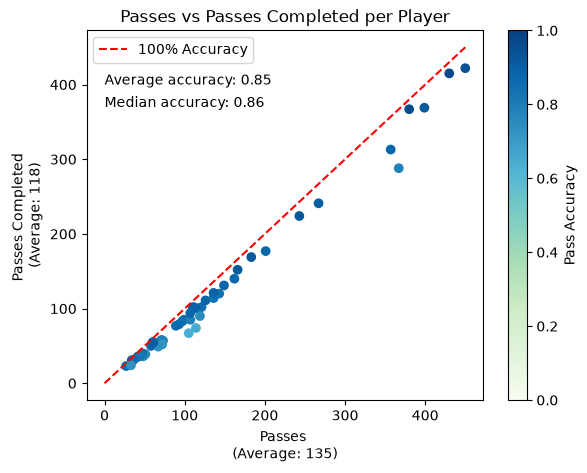

In [23]:
plt.plot([0, max(sample['Passes'])], [0, max(sample['Passes'])], linestyle='--', color='red', label='100% Accuracy')
plt.scatter(sample['Passes'], sample['Passes Completed'], c=sample['Passes Completed']/sample['Passes'], cmap='GnBu', vmin=0, vmax=1)
plt.title('Passes vs Passes Completed per Player')
plt.xlabel(f'Passes \n(Average: {sample['Passes'].mean():.0f})')
plt.ylabel(f'Passes Completed \n(Average: {sample['Passes Completed'].mean():.0f})')
plt.colorbar(label='Pass Accuracy')

plt.text(0, 400, f'Average accuracy: {sample['Passing Accuracy Rate'].mean():.2f}')
plt.text(0, 370, f'Median accuracy: {sample['Passing Accuracy Rate'].median():.2f}')


plt.legend()

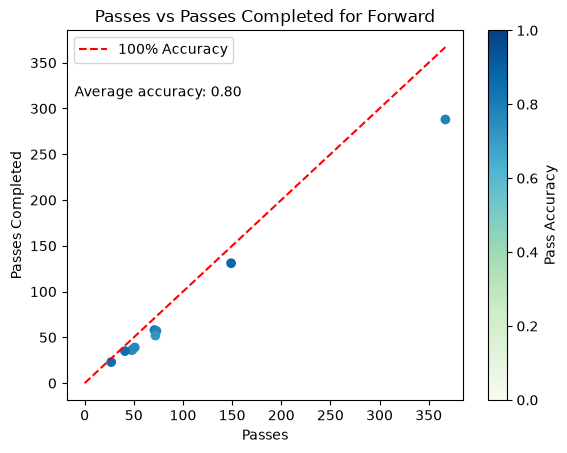

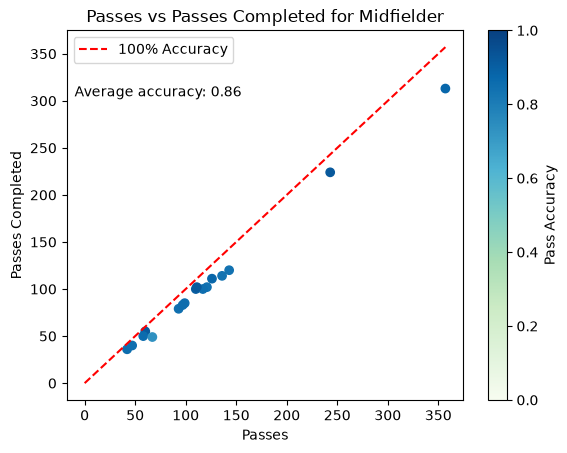

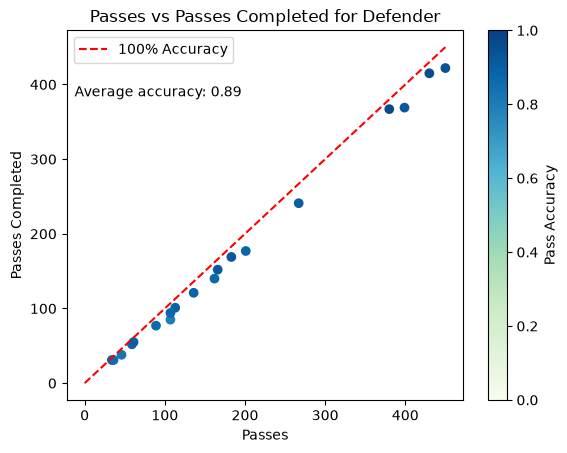

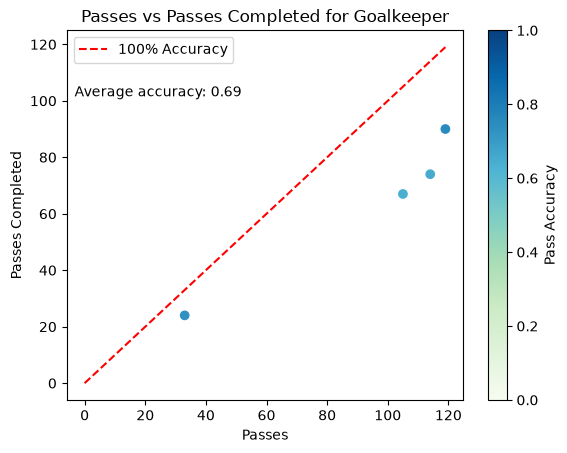

In [24]:
for pos in sample['Position'].unique():
    temp_sample = sample[sample['Position'] == pos]
    plt.scatter(temp_sample['Passes'], temp_sample['Passes Completed'], c=temp_sample['Passes Completed']/temp_sample['Passes'], cmap='GnBu', vmin=0, vmax=1)
    plt.title(f'Passes vs Passes Completed for {pos}')
    plt.xlabel('Passes')
    plt.ylabel('Passes Completed')
    plt.colorbar(label='Pass Accuracy')
    plt.plot([0, max(temp_sample['Passes'])], [0, max(temp_sample['Passes'])], linestyle='--', color='red', label='100% Accuracy')

    plt.text(0.02, 0.85, f'Average accuracy: {temp_sample['Passing Accuracy Rate'].mean():.2f}', ha='left',va='top', transform=plt.gca().transAxes)
    

    plt.legend()
    plt.show()

## Box plot

In [25]:
features = ['Passes', 'Passes Completed', 'Passing Accuracy Rate', 'Age']

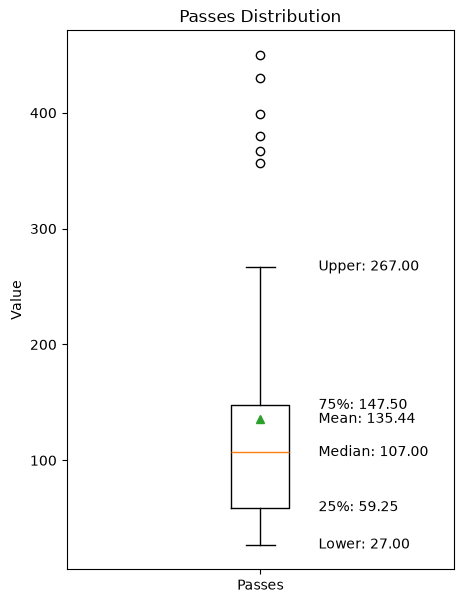

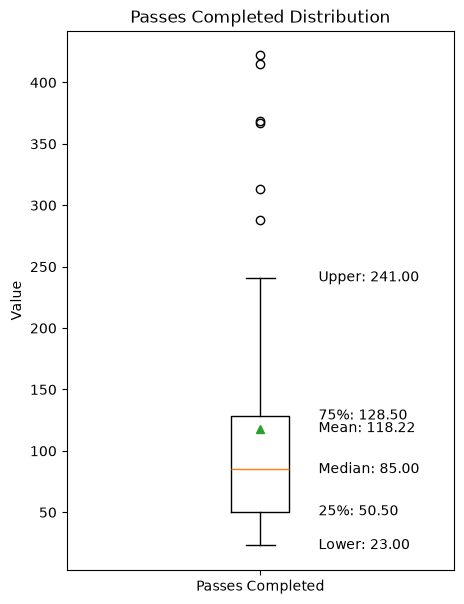

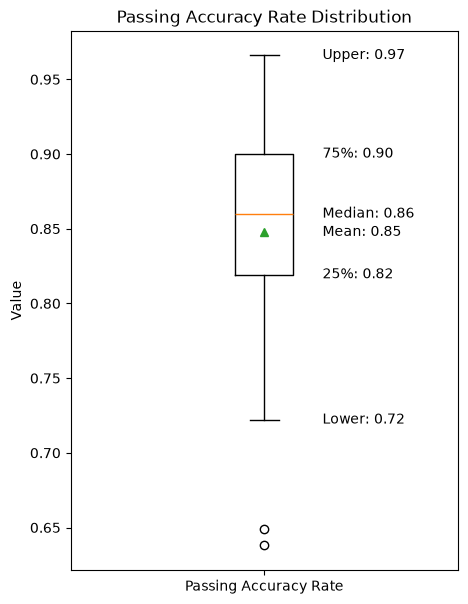

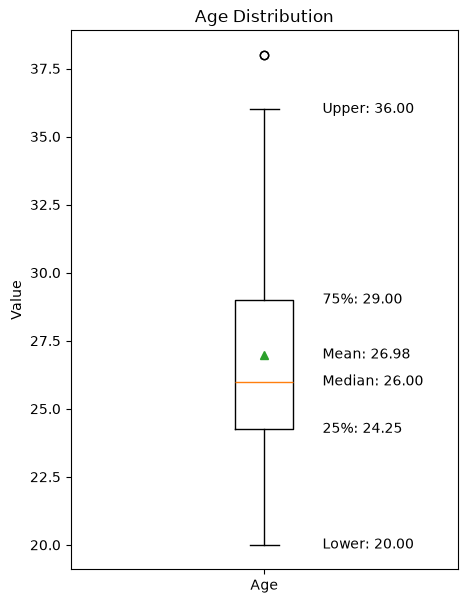

In [27]:
for feature in features:
        stats = boxplot_stats(sample[feature])[0]
        labels = {
                'Lower': stats['whislo'],
                '25%': stats['q1'],
                'Median': stats['med'],
                'Mean': stats['mean'],
                '75%': stats['q3'],
                'Upper': stats['whishi'],
                }

        plt.figure(figsize=(5, 7))

        plt.boxplot([sample[feature]], tick_labels=[feature], showmeans=True)

        plt.title(f'{feature} Distribution')
        plt.ylabel('Value')
        for name, value in labels.items():
                plt.text(
                        1.15,                 
                        value,
                        f'{name}: {value:.2f}',
                        va='center'
                )
        plt.show()

## Confidence Interval

In [28]:
import statsmodels.stats.weightstats as stm
import scipy.stats as st
import math

In [29]:
# Confidence Level
conf_lvl = 0.95

# alpha
alpha = 1 - conf_lvl
print("Alpha: %.2f" % alpha)

# determine degrees of freedom (required when using t-statistic)
dof = len(sample) - 1
print("Degrees of freedom: %d" % dof)

Alpha: 0.05
Degrees of freedom: 49


In [30]:
for feature in ['Passes', 'Passes Completed', 'Passing Accuracy Rate']:
    # Mean, std and std error
    x_bar = st.tmean(sample[feature])
    s = st.tstd(sample[feature])
    std_err = s / math.sqrt(len(sample))
    print(f"{feature} \n Mean: {x_bar} \n Standard deviation: {s} \n Standard error: {std_err}")

    # CI
    ci_low, ci_upp = stm._tconfint_generic(x_bar, std_err, dof, alpha, 'two-sided')
    print(f'Upper bound: {ci_low}, Lower bound: {ci_upp}')

Passes 
 Mean: 135.44 
 Standard deviation: 111.15537204604138 
 Standard error: 15.719743467813892
Upper bound: 103.84999279305708, Lower bound: 167.0300072069429
Passes Completed 
 Mean: 118.22 
 Standard deviation: 104.27716011883417 
 Standard error: 14.74701740858061
Upper bound: 88.5847589942026, Lower bound: 147.8552410057974
Passing Accuracy Rate 
 Mean: 0.8476 
 Standard deviation: 0.0737693592716308 
 Standard error: 0.010432562836951369
Upper bound: 0.8266349800630678, Lower bound: 0.8685650199369322


In [65]:
no_of_sample = 5000
test_sample = pd.DataFrame()
mean_sample = []
for i in range(no_of_sample):
    
    test_sample = df.sample(50)
    mean_sample.append(test_sample['Passing Accuracy Rate'].mean())

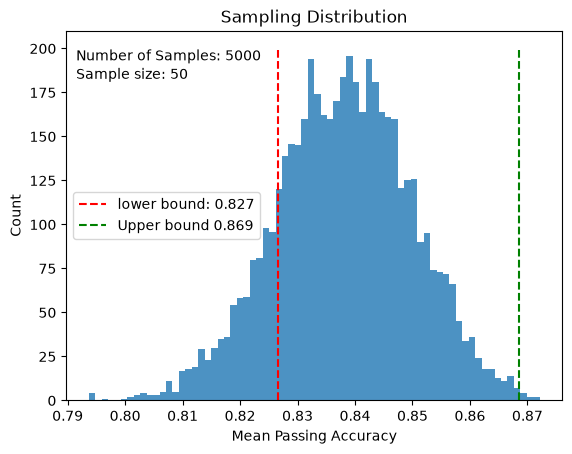

In [70]:
plt.hist(mean_sample,70, alpha=0.8)
plt.title('Sampling Distribution')
plt.xlabel('Mean Passing Accuracy')
plt.ylabel('Count')
plt.text(0.02,0.95,f'Number of Samples: {no_of_sample}', ha='left', va='top', transform=plt.gca().transAxes)
plt.text(0.02,0.90,f'Sample size: {sample_size}', ha='left', va='top', transform=plt.gca().transAxes)
plt.plot([ci_low,ci_low], [0, 200], linestyle='--', color='red', label=f'lower bound: {ci_low:.3f}')
plt.plot([ci_upp,ci_upp], [0, 200], linestyle='--', color='green', label=f'Upper bound {ci_upp:.3f}')
plt.legend()




## T-test

### Was the mean passing accuracy different between young player group and old player group

<b>null hypothesis</b>: mean passing accuracy of sample 1 (younger) equals mean passing accuracy of sample 2 (older) \
<b>alternative hypothesis</b>: mean passing accuracy of sample 1 (younger) does not equal mean passing accuracy of sample 2 (older)

In [85]:
# Sampling younger players
sample_younger = pd.DataFrame()
for position in df['Position'].unique():
    sample_pos = df[(df['Position'] == position) & (df['Age Group'] == 'Younger')]
    temp_sample = sample_pos.sample(pos_observation[position],random_state = 10)
    sample_younger = pd.concat([sample_younger, temp_sample])

In [84]:
# Sampling older players
sample_older = pd.DataFrame()
for position in df['Position'].unique():
    sample_pos = df[(df['Position'] == position) & (df['Age Group'] == 'Older')]
    temp_sample = sample_pos.sample(pos_observation[position],random_state = 10)
    sample_older = pd.concat([sample_older, temp_sample])

In [86]:
print(sample_younger['Position'].value_counts())

Position
Defender      19
Midfielder    17
Forward       10
Goalkeeper     4
Name: count, dtype: int64


In [78]:
print(sample_older['Position'].value_counts())


Position
Defender      19
Midfielder    17
Forward       10
Goalkeeper     4
Name: count, dtype: int64


In [87]:
x_bar_younger = st.tmean(sample_younger['Passing Accuracy Rate'])
std_younger = st.tstd(sample_younger['Passing Accuracy Rate'])
print(f"Passing Accuracy Rate for Younger sample \n Mean: {x_bar_younger} \n Standard deviation: {std_younger}")

Passing Accuracy Rate for Younger sample 
 Mean: 0.8231400000000001 
 Standard deviation: 0.08733725623427044


In [88]:
x_bar_older = st.tmean(sample_older['Passing Accuracy Rate'])
std_older = st.tstd(sample_older['Passing Accuracy Rate'])
print(f"Passing Accuracy Rate for Older sample \n Mean: {x_bar_older} \n Standard deviation: {std_older}")

Passing Accuracy Rate for Older sample 
 Mean: 0.8422799999999999 
 Standard deviation: 0.09603422859181246


In [ ]:
t_stats, p_val = st.ttest_ind_from_stats(x_bar_younger,std_younger, len(sample_younger), 
                                         x_bar_older, std_older, len(sample_older), False, 'two-sided')

In [116]:
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)
    
print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)


 Computing t* ...
	 t-statistic (t*): 1.04

 Computing p-value ...
	 p-value: 0.2997


In [91]:
print("\n Conclusion:")
if p_val < 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We fail to reject the null hypothesis.")


 Conclusion:
	 We fail to reject the null hypothesis.


## t-test visualisation

In [110]:
no_of_sample = 5000
test_sample = pd.DataFrame()
mean_sample_younger = []
temp_sample = df[df['Age Group'] == 'Younger']
for i in range(no_of_sample):
    test_sample = temp_sample.sample(50)
    mean_sample_younger.append(test_sample['Passing Accuracy Rate'].mean())

In [108]:
mean_sample_older = []
temp_sample = df[df['Age Group'] == 'Older']
for i in range(no_of_sample):
    test_sample = temp_sample.sample(50)
    mean_sample_older.append(test_sample['Passing Accuracy Rate'].mean())

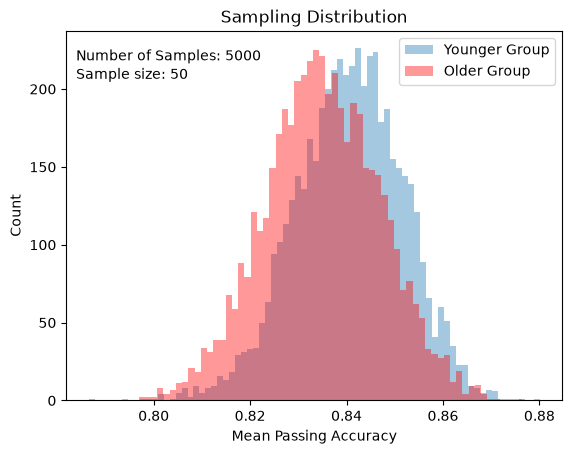

In [121]:
plt.hist(mean_sample_younger,70, alpha=0.4, label='Younger Group')
plt.hist(mean_sample_older,70, alpha=0.4, color='red', label='Older Group')
plt.title('Sampling Distribution')
plt.xlabel('Mean Passing Accuracy')
plt.ylabel('Count')
plt.text(0.02,0.95,f'Number of Samples: {no_of_sample}', ha='left', va='top', transform=plt.gca().transAxes)
plt.text(0.02,0.90,f'Sample size: {sample_size}', ha='left', va='top', transform=plt.gca().transAxes)
plt.legend()

